## UNIL Field Camp Research Presentation

15 minute presentation.  Using moorings & CTD to investigate research questions on physical processes.

In [1]:
# imports
import ewgreaders as ewg
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.notebook import tqdm

In [5]:
lake = 'Zug'

di_ctd = ewg.get_data_index(lake, 'ctd')
di_m = ewg.get_data_index(lake, 'mooring')

### Lake map and obsevation locations

In [13]:
bathy = xr.open_dataset(f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/bathymetry.nc')

locs = pd.DataFrame([
    {'loc': 'N', 'xsc': 679227, 'ysc': 220396, 'color':'tab:red',},
    {'loc': 'W', 'xsc': 679917, 'ysc': 218754, 'color': 'tab:orange'},
    {'loc': 'C', 'xsc': 680091, 'ysc': 218814, 'color': 'tab:blue'},
    {'loc': 'E', 'xsc': 680326, 'ysc': 218879, 'color': 'tab:green'},
    {'loc': 'S', 'xsc': 680442, 'ysc': 216813, 'color': 'tab:purple'}
])

locs['xsc'] = locs['xsc'] + int(2e6)
locs['ysc'] = locs['ysc'] + int(1e6)

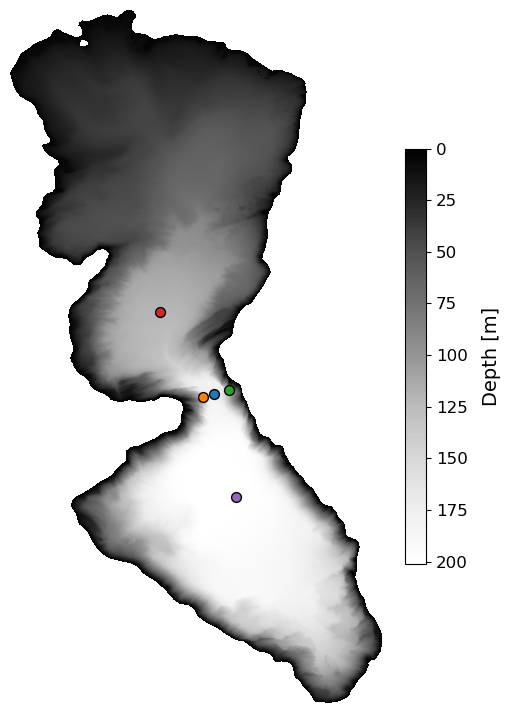

In [41]:
fig, ax = plt.subplots(figsize=(6, 9))

im = ax.pcolormesh(bathy['xsc'], bathy['ysc'], bathy['depth'], cmap='Greys_r', vmin=0, rasterized=True)
cbar = fig.colorbar(im, shrink=0.6, ax=ax)
cbar.set_label('Depth [m]', fontsize=14, labelpad=10)
cbar.ax.tick_params(labelsize=12)
cbar.ax.invert_yaxis()

for _, loc in locs.iterrows():
    ax.scatter(loc['xsc'], loc['ysc'], color=loc['color'], s=50, edgecolor='k')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../../gallery/unil_field_camp/2026/zug_map_locs.svg', bbox_inches='tight')
plt.show()

### Gravity/Interfacial Current

In [6]:
t_start = '2025-10-31'
t_end = '2026-04-10'

di_ctd_sel = di_ctd[di_ctd['date'].between(t_start, t_end)]

# cooling period
t0 = pd.to_datetime('2025-12-16')
tf = pd.to_datetime('2026-01-31')

#### Surface cooling
- Air temperature from Cham meteo station
- Water (surface) temperature from CTD

In [ ]:
all_ds = []
for year in ['2025', '2026']:
    meteo_path = f'Q:/Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Meteo/meteo_cham.nc'
    ds = xr.open_dataset(meteo_path)
    all_ds.append(ds)

ds_meteo = xr.concat(all_ds, dim='time')
ds_meteo = ds_meteo.sel(time=slice(t_start, t_end))

# air temperature, 1-day rolling average
air_temp = ds_meteo['air_temp']
air_temp_ra = air_temp.rolling(time=6*24, center=True).mean()

In [ ]:
surf_temp = []
for _, p in tqdm(di_ctd_sel.iterrows(), total=len(di_ctd_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()
    surf_temp.append({
        'date': p.date,
        'temp': ds['temp'].isel(depth=0).item()
    })

surf_temp = pd.DataFrame(surf_temp)
surf_temp = surf_temp.groupby('date').mean().reset_index()

  0%|          | 0/187 [00:00<?, ?it/s]

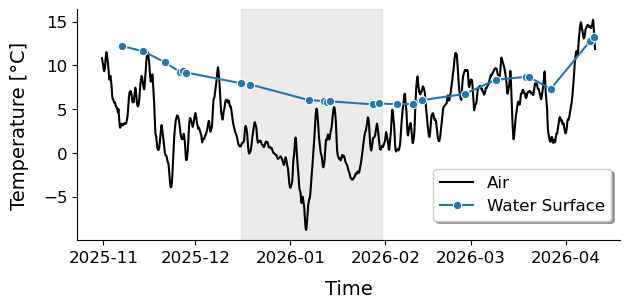

In [52]:
fig, ax = plt.subplots(figsize=(7, 3))

ax.axvspan(t0, tf, color='silver', alpha=0.3)
sns.lineplot(x=air_temp_ra.time, y=air_temp_ra, color='black', ax=ax, label='Air')
sns.lineplot(surf_temp, x='date', y='temp', color='tab:blue', marker='o', ax=ax, errorbar=('se', 1), err_style='band', label='Water Surface')

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Temperature [°C]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

ax.legend(fontsize=12, ncols=1, shadow=True, loc='lower right', bbox_to_anchor=(1, 0.05))

plt.savefig('../../gallery/unil_field_camp/2026/air_surfwater_temp.svg', bbox_inches='tight')
plt.show()

#### Interface depth
- Pycnocline (CTD)

In [32]:
# constriction profiles (to match location of ADCP data)
pl_c = ["P6", "VMPC", "PC", "P7"]
di_ctd_sel = di_ctd[(di_ctd['date'].between(t0, tf)) & (di_ctd['profile_loc'].isin(pl_c))]

data = []
for _, p in tqdm(di_ctd_sel.iterrows(), total=len(di_ctd_sel)):
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()
    rho = ds['rho']
    rho_ba = ewg.signal.binned_average_z(rho)
    dat = pd.DataFrame({'depth': rho_ba.depth, 'rho': rho_ba})
    dat[['date', 'time']] = ds.attrs['date'], ds.attrs['time']
    data.append(dat)

data = pd.concat(data, ignore_index=True)

# for plotting
data = data[data['depth'] > 5]
data['rho'] = data['rho'] - 1e3

  0%|          | 0/21 [00:00<?, ?it/s]

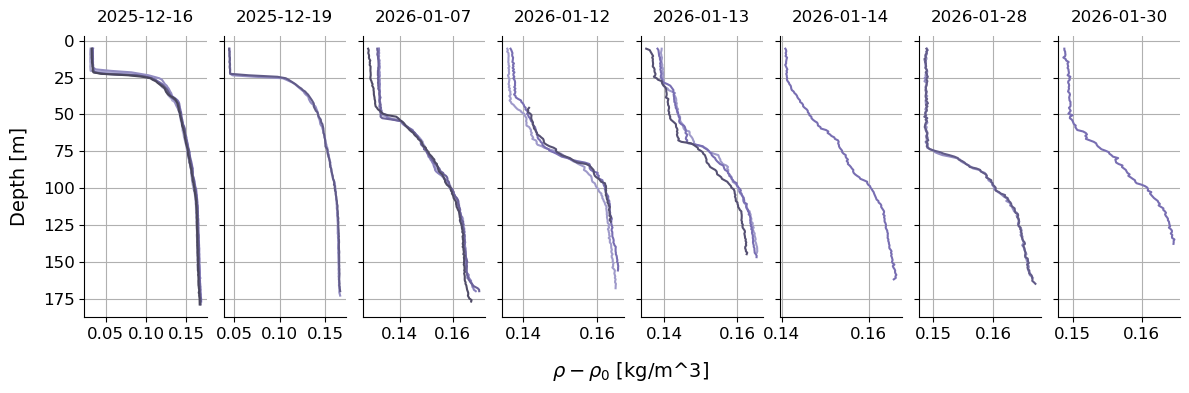

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=data['date'].nunique(), figsize=(12, 4), sharey=True)

for i, (t, dat) in enumerate(data.groupby('date')):
    sns.lineplot(dat, x='rho', y='depth', orient='y', hue='time', palette='Purples_d', ax=ax[i], legend=False)

    ax[i].set_xlabel('')
    ax[i].set_title(t, fontsize=12, pad=10)
    ax[i].tick_params(axis='both', labelsize=12)

    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
fig.supxlabel(r'$\rho - \rho_{0}$ [kg/m^3]', fontsize=14, x=0.53, y=0.03)

ax[0].invert_yaxis()

plt.tight_layout(w_pad=0)
plt.savefig('../../gallery/unil_field_camp/2026/rho_pycnocline.svg', bbox_inches='tight')
plt.show()

#### Flow from N to S basin
- Current velocity at constriction (ADCP)

In [7]:
def load_adcp_chain(di, gap):
    # ADCP
    all_adcp = []
    for _, row in di.iterrows():
        mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
        deploy, retrieve = mreader.get_deploy_retrieve_dates()
        t_start = deploy + pd.Timedelta(days=1)
        t_end = retrieve - pd.Timedelta(days=1)
        areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
        ds = areader.load().sel(time=slice(t_start, t_end))
        ds['depth'] = ds['depth'].round(0)
        ds = ewg.signal.valid_depths(ds, 0.5)    # keep depth bins with > 50% data
        all_adcp.append(ds)

    # shared time axis as mean of each instruments times
    time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp], axis=0).astype('datetime64[ns]'))
    all_adcp_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp]

    # concatenate datasets and average common range bins
    ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
    ds_adcp = ds_adcp.sortby('depth')
    ds_adcp = ds_adcp.groupby('depth').mean()

    # don't interplate over gap from opposite looking ADCPs in double frame
    full_depth = np.sort(np.concatenate([ds_adcp.depth.values, gap]))
    ds_adcp = ds_adcp.reindex(depth=full_depth)

    return ds_adcp

In [8]:
date = '2026-01-14'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(67, 77)

ds_adcp = load_adcp_chain(di_m_sel, gap)
vel1 = ds_adcp.vel.sel(time=slice(t0, tf))

C:\Users\herremha\AppData\Local\Temp\ipykernel_31904\1381314648.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_31904\1718629731.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [9]:
date = '2026-04-09'
loc = 'LZC'
di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
gap = np.arange(77, 87)

ds_adcp = load_adcp_chain(di_m_sel, gap)
vel2 = ds_adcp.vel.sel(time=slice(t0, tf))

C:\Users\herremha\AppData\Local\Temp\ipykernel_31904\2926341980.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and location == @loc and sensor == 'adcp'")
C:\Users\herremha\AppData\Local\Temp\ipykernel_31904\1718629731.py:20: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [10]:
# align depths (interpolate over mismatched depth bins)
aligned_depth = np.arange(vel1.depth.min(), vel2.depth.max())
vel1_aligned = vel1.reindex(depth=aligned_depth, method='nearest', tolerance=1)
vel2_aligned = vel2.reindex(depth=aligned_depth, method='nearest', tolerance=1)
vel = xr.concat([vel1_aligned, vel2_aligned], dim="time")

# don't interplate over time gap
gap = pd.date_range(vel1.time.values[-1], vel2.time.values[0], freq='10min')
full_time = np.sort(np.concatenate([vel.time.values, gap]))
vel = vel.reindex(time=full_time)

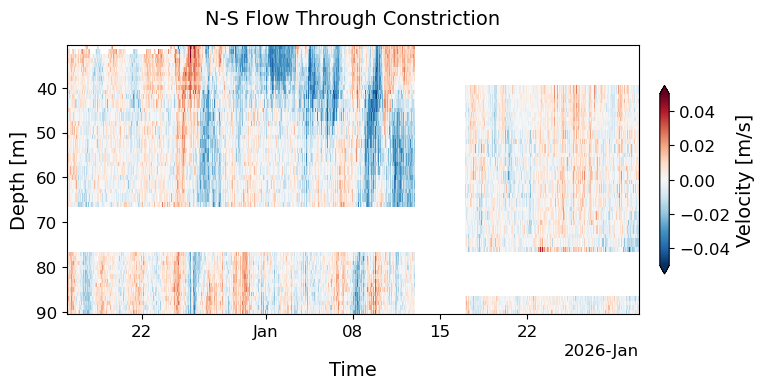

In [17]:
fig, ax = plt.subplots(figsize=(9, 3.5))

pc = vel.sel(depth=slice(None, 90), dir='N').plot(x='time', y='depth', cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'shrink': 0.7, 'pad': 0.03, 'label': 'Velocity [m/s]'}, ax=ax, rasterized=True)
pc.colorbar.ax.yaxis.label.set_size(14)
pc.colorbar.ax.tick_params(labelsize=12)

ax.set_xlabel('Time', fontsize=14, labelpad=15)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=5)
ax.set_title('N-S Flow Through Constriction', fontsize=14, pad=15)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.invert_yaxis()

plt.savefig('../../gallery/unil_field_camp/2026/vel_interfacial_current.svg', bbox_inches='tight')
plt.show()

#### Volume transport

~30-75 meters depth range

In [14]:
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)
xsc, ysc = mreader.get_swiss_coords()

# 30-75 m depth range
v_sel = vel.sel(depth=slice(None, 75), dir='N')

h = 1    # ADCP cell size

flux = []
coords = []
for d in tqdm(v_sel.depth.values, total=len(v_sel.depth)):
    xsc1, ysc1, xsc2, ysc2, distance = ewg.datsci.lakes.locate_interface_bounds(d, xsc, ysc, 0, bathy, oom=False)
    da = distance * h
    v = v_sel.sel(depth=d)
    flux.append((v * da).rename('flux'))
    coords.append({
        'depth': d,
        'xsc1': xsc1,
        'ysc1': ysc1,
        'xsc2': xsc2,
        'ysc2': ysc2
    })
    
ds_flux = xr.concat(flux, dim='depth')
ds_flux = ds_flux.dropna(dim='time', how='all')   # remove times with no data (mooring out of water)

  0%|          | 0/45 [00:00<?, ?it/s]

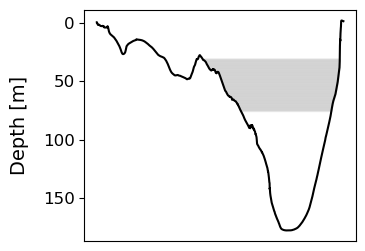

In [22]:
fig, ax = plt.subplots(figsize=(3.5, 3))

bathy.sel(ysc=ysc).depth.plot(color='black', ax=ax)

for c in coords:
    ax.fill_between(np.arange(c['xsc2'], c['xsc1']), c['depth'] - h/2, c['depth'] + h/2, color='silver', alpha=0.3)

ax.set_xlabel('')
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('')
ax.set_xticks([])
ax.tick_params(axis='both', labelsize=12)

ax.invert_yaxis()

plt.savefig('../../gallery/unil_field_camp/2026/coronal_da.svg', bbox_inches='tight')
plt.show()

In [18]:
# daily net volume transport, averaged over depth range
transport = ds_flux.groupby("time.date").apply(ewg.datsci.lakes.net_volume_transport).mean(dim='depth')

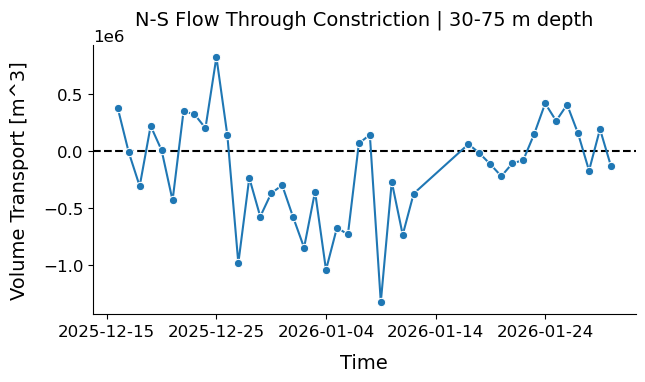

In [20]:
fig, ax = plt.subplots(figsize=(7, 3.5))

ax.axhline(0, color='black', linestyle='--')
sns.lineplot(x=transport.date, y=transport, color='tab:blue', marker='o', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Volume Transport [m^3]', fontsize=14, labelpad=10)
ax.set_title('N-S Flow Through Constriction | 30-75 m depth', fontsize=14, pad=15)
ax.tick_params(axis='both', labelsize=12)
ax.yaxis.get_offset_text().set_fontsize(12)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=10))

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../../gallery/unil_field_camp/2026/transport_interfacial_current.svg', bbox_inches='tight')
plt.show()

### Boundary Mixing

Thorpe scale (80-110 m) comparing N/S Basin, Constriction West/Center/East.

In [30]:
p = di_ctd.iloc[196]
ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
ds = ctdreader.load()

# thorpe displacement
rho = ds['rho']
depth = ds['depth']
rho_ra = ewg.signal.rolling_average_z(rho)
rho_ra_sort = ewg.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
thorpe_displacement = (depth - rho_ra_sort.depth.values).rename('thorpe_displacement')

# re-assing depth to sorted profile for plotting
rho_ra_sort = ewg.signal.order_profile(rho_ra, surfmax=False, reassign_depth=True)

In [37]:
rho_ra_sort.diff(dim='depth').min()

<xarray.DataArray 'rho' ()> Size: 8B
array(0.)

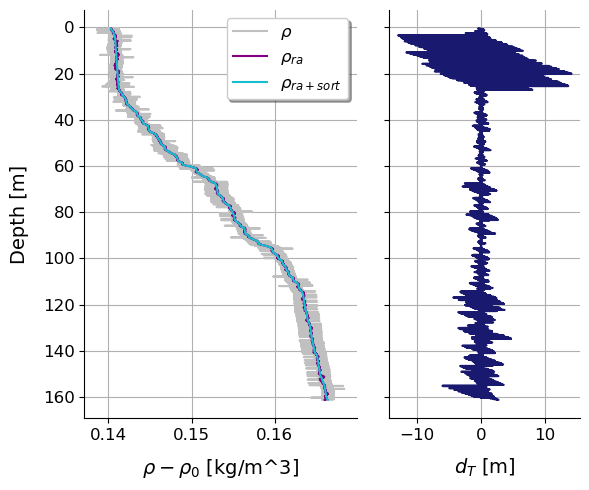

In [41]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 5), sharey=True, width_ratios=[1, 0.7])

sns.lineplot(x=rho - 1e3, y=rho.depth, orient='y', color='silver', ax=ax[0], label=r'$\rho$')
sns.lineplot(x=rho_ra - 1e3, y=rho_ra.depth, orient='y', color='purple', ax=ax[0], label=r'$\rho_{ra}$')
sns.lineplot(x=rho_ra_sort - 1e3, y=rho_ra_sort.depth, orient='y', color='tab:cyan', ax=ax[0], label=r'$\rho_{ra + sort}$')
sns.lineplot(x=thorpe_displacement, y=thorpe_displacement.depth, orient='y', color='midnightblue', ax=ax[1])

ax[0].set_xlabel(r'$\rho - \rho_{0}$ [kg/m^3]', fontsize=14, labelpad=10)
ax[1].set_xlabel(r'$d_{T}$ [m]', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

ax[0].legend(fontsize=12, shadow=True)
ax[0].invert_yaxis()

plt.tight_layout(w_pad=2)
plt.savefig('../../gallery/unil_field_camp/2026/thorpe_displacement.svg', bbox_inches='tight')
plt.show()

In [353]:
pl_n = ["P4", "VMPN"]
pl_w = ["P6W", "VMPW"]
pl_c = ["P6", "VMPC", "PC", "P7"]
pl_e = ["P6E"]
pl_s = ["P10", "VMPS", "LZ3"]

all_pl = [set(pl_n), set(pl_w), set(pl_c), set(pl_e), set(pl_n)]

In [364]:
data = []
for dt, di_ctd_sel in tqdm(di_ctd.groupby('date'), total=di_ctd['date'].nunique()):
    pl = set(di_ctd_sel.profile_loc)
    if all(pl.intersection(basin) for basin in all_pl):
        for _, p in di_ctd_sel.iterrows():
            if p.profile_loc in pl_n + pl_w + pl_c + pl_e + pl_s:
                ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
                ds = ctdreader.load()
                
                if ds['depth'].max() < 110:
                    continue
                
                # select out below 80 meters (hypolimion/deep water)
                ds = ds.sel(depth=slice(80, 110))
                
                # thorpe displacement
                rho = ds['rho']
                depth = ds['depth']
                rho_ra = ewg.signal.rolling_average_z(rho)
                rho_ra_sort = ewg.signal.order_profile(rho_ra, surfmax=False, reassign_depth=False)
                thorpe_displacement = depth - rho_ra_sort.depth.values
                thorpe_scale = np.sqrt((thorpe_displacement**2).mean()).item()

                data.append({
                    'date': p.date,
                    'profile_loc': p.profile_loc,
                    'basin': 'N' if p.profile_loc in pl_n else 'W' if p.profile_loc in pl_w else 'C' if p.profile_loc in pl_c else 'E' if p.profile_loc in pl_e else 'S',
                    'thorpe_scale': thorpe_scale
                })

data = pd.DataFrame(data)

  0%|          | 0/39 [00:00<?, ?it/s]

In [366]:
# baseline correct by day mean
data['thorpe_scale_bc'] = data['thorpe_scale'] - data.groupby('date')['thorpe_scale'].transform('mean')

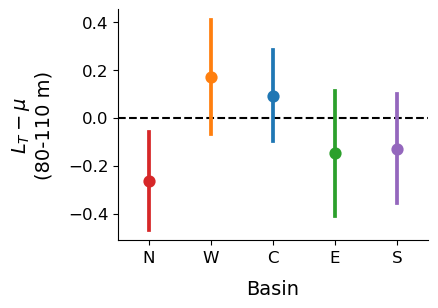

In [387]:
fig, ax = plt.subplots(figsize=(4, 3))
order = ['N', 'W', 'C', 'E', 'S']
palette = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green', 'tab:purple']

ax.axhline(0, color='black', linestyle='--')
sns.pointplot(data, x='basin', y='thorpe_scale_bc', estimator=np.mean, order=order, hue='basin', hue_order=order, palette=palette, errorbar=('se', 1), linestyle='none', ax=ax)

ax.set_xlabel('Basin', fontsize=14, labelpad=10)
ax.set_ylabel(r'$L_{T} - \mu$' + '\n(80-110 m)', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
#ax.set_ylim(0, None)

plt.savefig('../../gallery/unil_field_camp/2026/thorpe_scale_basin.svg', bbox_inches='tight')
plt.show()

#### Temperature Overturns

Constriction west v. center v. east

In [42]:
def load_thermistor_chain(di, t_start='2026-02-06', t_end='2026-04-08'):
    all_temp = []
    for _, row in di.iterrows():
        mreader = ewg.mooring_reader.MooringReader(row.lake, row.date, row.location)
        deploy, retrieve = mreader.get_deploy_retrieve_dates()
        #t_start = deploy + pd.Timedelta(days=1)
        #t_end = retrieve - pd.Timedelta(days=1)
        treader = ewg.thermistor_reader.ThermistorReader(row.lake, row.date, row.location, row.serial_id)
        ds = treader.load().sel(time=slice(t_start, t_end))
        all_temp.append(ds)

    ds_temp = mreader.create_instrument_chain(all_temp)

    return ds_temp

In [43]:
date = '2026-04-09'
thermistors = ['rbr_temp', 'rbr_duet']
di_m_sel = di_m.query("date == @date and sensor in @thermistors")

# LZW
di_w = di_m_sel.query("location == 'LZW'")
ds_temp_w = load_thermistor_chain(di_w).temp

# LZC
di_c = di_m_sel.query("location == 'LZC'")
ds_temp_c = load_thermistor_chain(di_c).temp.sel()

# LZE
di_e = di_m_sel.query("location == 'LZE'")
ds_temp_e = load_thermistor_chain(di_e).temp

C:\Users\herremha\AppData\Local\Temp\ipykernel_31904\3412455176.py:3: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  di_m_sel = di_m.query("date == @date and sensor in @thermistors")
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:229: FutureWarning: In a fut

In [44]:
z_min = 100
z_max = 105

tw_top = ds_temp_w.sel(depth=z_min, method='nearest')
tw_bot = ds_temp_w.sel(depth=z_max, method='nearest')

tc_top = ds_temp_c.sel(depth=z_min, method='nearest')
tc_bot = ds_temp_c.sel(depth=z_max, method='nearest')

te_top = ds_temp_e.sel(depth=z_min, method='nearest')
te_bot = ds_temp_e.sel(depth=z_max, method='nearest')

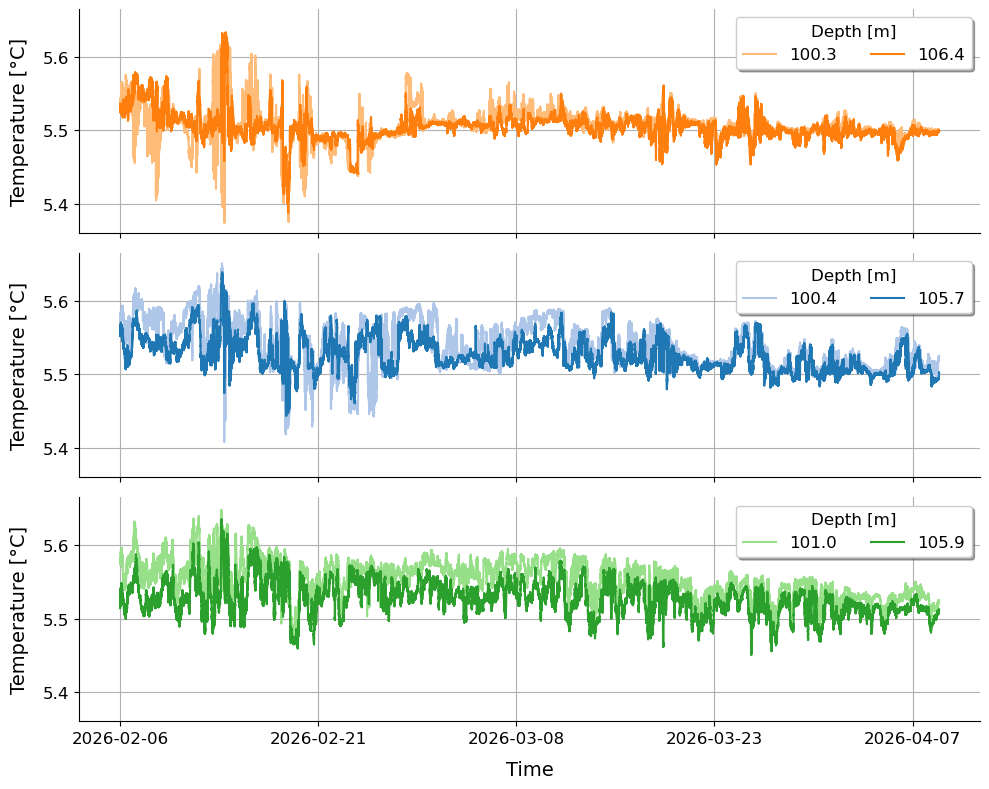

In [45]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True, sharey=True)
palette = sns.color_palette('tab20', n_colors=6)

# LZW
sns.lineplot(x=tw_top.time, y=tw_top, color=palette[3], ax=ax[0], label=tw_top.depth.item())
sns.lineplot(x=tw_bot.time, y=tw_bot, color=palette[2], ax=ax[0], label=tw_bot.depth.item())

# LZC
sns.lineplot(x=tc_top.time, y=tc_top, color=palette[1], ax=ax[1], label=tc_top.depth.item())
sns.lineplot(x=tc_bot.time, y=tc_bot, color=palette[0], ax=ax[1], label=tc_bot.depth.item())

# LZE
sns.lineplot(x=te_top.time, y=te_top, color=palette[5], ax=ax[2], label=te_top.depth.item())
sns.lineplot(x=te_bot.time, y=te_bot, color=palette[4], ax=ax[2], label=te_bot.depth.item())

ax[2].set_xlabel('Time', fontsize=14, labelpad=10)
ax[2].xaxis.set_major_locator(mdates.DayLocator(interval=15))

for i in range(len(ax)):
    ax[i].set_ylabel('Temperature [°C]', fontsize=14, labelpad=10)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)
    ax[i].legend(ncols=2, title='Depth [m]', fontsize=12, title_fontsize=12, shadow=True, loc='upper right')

plt.tight_layout()
plt.savefig('../../gallery/unil_field_camp/2026/temp_overturn_ts.svg', bbox_inches='tight')
plt.show()

In [495]:
overturn_w = tw_top < tw_bot
overturn_c = tc_top < tc_bot
overturn_e = te_top < te_bot

df_ow = overturn_w.groupby('time.date').mean().to_dataframe().reset_index()
df_ow['location'] = 'W'

df_oc = overturn_c.groupby('time.date').mean().to_dataframe().reset_index()
df_oc['location'] = 'C'

df_oe = overturn_e.groupby('time.date').mean().to_dataframe().reset_index()
df_oe['location'] = 'E'

df = pd.concat([df_ow, df_oc, df_oe], ignore_index=True)

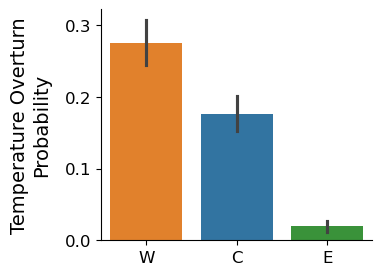

In [519]:
fig, ax = plt.subplots(figsize=(3.5, 3))
order = ['W', 'C', 'E']
palette = ['tab:orange', 'tab:blue', 'tab:green']

sns.barplot(df, x='location', y='temp', order=order, hue='location', hue_order=order, palette=palette, errorbar=('se', 1), ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Temperature Overturn\nProbability', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig('../../gallery/unil_field_camp/2026/temp_overturn_prop.svg', bbox_inches='tight')
plt.show()